# WSEI Lab 03 – Zadanie 1: GAN

## Cel
Zaprojektowanie, implementacja i analiza **generatywnej sieci adwersarialnej (GAN)** generującej nowe dane podobne do zbioru uczącego.

## Zakres
1. Dwa zbiory danych: **MNIST** i **Fashion-MNIST**
2. Architektura **generatora (G)** i **dyskryminatora (D)** – DCGAN
3. Funkcje straty (BCE) i procedura treningu adwersarialnego
4. Uczenie modelu
5. Wizualizacja próbek na epokach 1, 5, 10, 15
6. Analiza stabilności treningu i jakości generacji

Kod wspólny: moduł `lab03/gan.py` w repozytorium.

In [ ]:

# %pip install torch torchvision matplotlib

In [1]:
%matplotlib inline

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch

ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from lab03.gan import (
    GANConfig,
    Discriminator,
    Generator,
    display_results_in_notebook,
    train_gan,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUT = Path("./outputs/lab03_zadanie1_gan")

cfg = GANConfig(
    latent_dim=100,
    batch_size=128,
    epochs=15,
    lr=2e-4,
    snapshot_epochs=(1, 5, 10, 15),
    num_workers=0,
)

print("Device:", device)
print("Output:", OUT.resolve())
print("Epoki:", cfg.epochs, "| snapshot:", cfg.snapshot_epochs)

Device: cuda
Output: C:\Users\mateu\Desktop\projects\wsei-deep-learning\outputs\lab03_zadanie1_gan
Epoki: 15 | snapshot: (1, 5, 10, 15)


## 1. Architektura G i D

| Sieć | Warstwy | Aktywacje |
|------|---------|----------|
| **Generator G** | ConvTranspose2d (100→256→128→1), BatchNorm | ReLU, **Tanh** ([-1,1]) |
| **Dyskryminator D** | Conv2d (1→64→128→1), BatchNorm | **LeakyReLU(0.2)**, **Sigmoid** |

**Straty:** `BCELoss` – D klasyfikuje real/fake; G maksymalizuje P(fake=real). Label smoothing: real=0.9, fake=0.1.

In [2]:
G = Generator(cfg.latent_dim)
D = Discriminator()

print("--- Generator (G) ---")
print(G)
print(f"Parametry G: {sum(p.numel() for p in G.parameters()):,}")

print("\n--- Dyskryminator (D) ---")
print(D)
print(f"Parametry D: {sum(p.numel() for p in D.parameters()):,}")

z = torch.randn(2, cfg.latent_dim, 1, 1)
print("\nTest kształtów:", G(z).shape, "->", D(G(z)).shape)

--- Generator (G) ---
Generator(
  (net): Sequential(
    (0): ConvTranspose2d(100, 256, kernel_size=(7, 7), stride=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(128, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): Tanh()
  )
)
Parametry G: 1,781,504

--- Dyskryminator (D) ---
Discriminator(
  (net): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): 

## 2. Trening GAN (MNIST + Fashion-MNIST)

Schemat adwersarialny: naprzemiennie aktualizujemy D (real vs fake), potem G (oszukiwanie D).

In [3]:
histories = {}

for name in ("mnist", "fashion_mnist"):
    title = "MNIST" if name == "mnist" else "Fashion-MNIST"
    print(f"\n{'='*55}\nTrening: {title}\n{'='*55}")
    histories[title] = train_gan(
        dataset_name=name,
        out_dir=OUT / name,
        device=device,
        cfg=cfg,
        seed=42 if name == "mnist" else 123,
    )

print(f"\nZapisano w: {OUT.resolve()}")


Trening: MNIST
[mnist] Epoch 1/15 | loss_D=1.0916 | loss_G=1.1017
[mnist] Epoch 2/15 | loss_D=0.9918 | loss_G=1.2402
[mnist] Epoch 3/15 | loss_D=0.9673 | loss_G=1.3062
[mnist] Epoch 4/15 | loss_D=0.9908 | loss_G=1.2884
[mnist] Epoch 5/15 | loss_D=1.0095 | loss_G=1.2746
[mnist] Epoch 6/15 | loss_D=1.0091 | loss_G=1.2721
[mnist] Epoch 7/15 | loss_D=1.0092 | loss_G=1.2881
[mnist] Epoch 8/15 | loss_D=1.0252 | loss_G=1.2780
[mnist] Epoch 9/15 | loss_D=1.0101 | loss_G=1.3022
[mnist] Epoch 10/15 | loss_D=1.0045 | loss_G=1.3146
[mnist] Epoch 11/15 | loss_D=1.0124 | loss_G=1.3134
[mnist] Epoch 12/15 | loss_D=1.0043 | loss_G=1.3408
[mnist] Epoch 13/15 | loss_D=1.0002 | loss_G=1.3461
[mnist] Epoch 14/15 | loss_D=0.9968 | loss_G=1.3539
[mnist] Epoch 15/15 | loss_D=1.0027 | loss_G=1.3560

Trening: Fashion-MNIST
[fashion_mnist] Epoch 1/15 | loss_D=0.6934 | loss_G=2.2713
[fashion_mnist] Epoch 2/15 | loss_D=0.7929 | loss_G=2.1133
[fashion_mnist] Epoch 3/15 | loss_D=1.0449 | loss_G=1.2429
[fashion_mni

## 3. Wyniki – wykresy strat i wygenerowane próbki

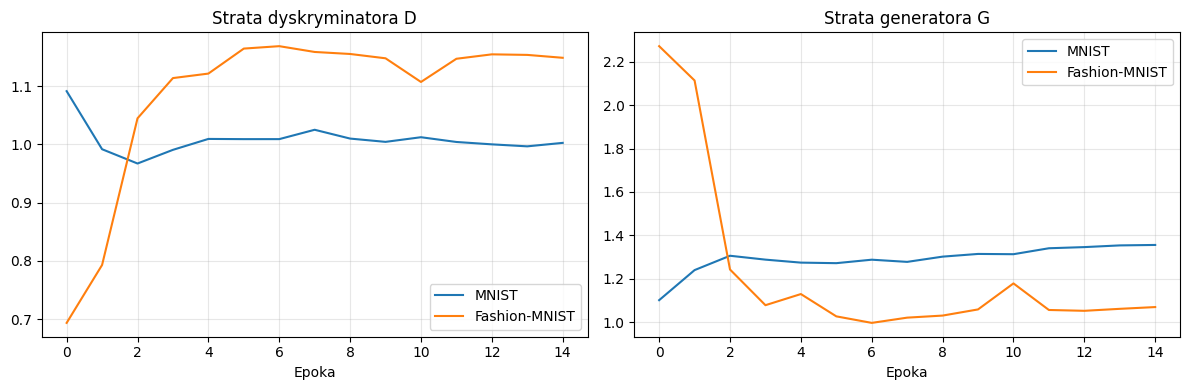

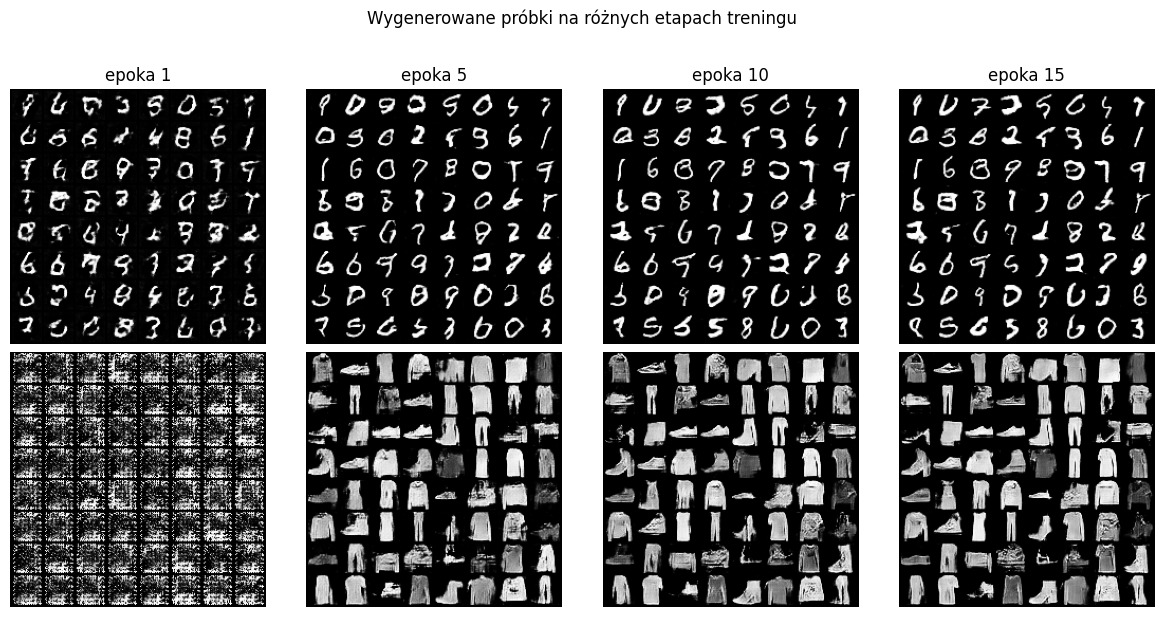


MNIST – próbki końcowe (samples_epoch_015.png):


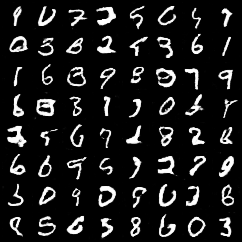


Fashion-MNIST – próbki końcowe (samples_epoch_015.png):


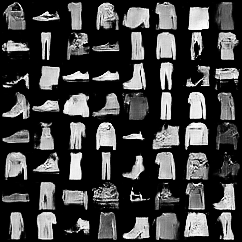

In [4]:
if not (OUT / "mnist").exists():
    raise FileNotFoundError(f"Brak wyników w {OUT}. Uruchom komórkę treningu powyżej.")

display_results_in_notebook(
    OUT,
    histories=histories if histories else None,
    snapshot_epochs=cfg.snapshot_epochs,
)

## 4. Analiza

### Stabilność treningu
- Obserwuj wykresy `loss_D` i `loss_G`. Duże oscylacje lub szybki spadek `loss_D` do ~0 przy rosnącym `loss_G` oznacza, że D „przeważa” nad G.
- **Label smoothing** (0.9 / 0.1) łagodzi ten efekt.
- MNIST zwykle trenuje się stabilniej niż Fashion-MNIST (prostsze obrazy).

### Jakość generacji
- **Epoka 1–5:** głównie szum, zarys kształtu.
- **Epoka 10–15:** rozpoznawalne cyfry / elementy ubrań.
- Fashion-MNIST bywa bardziej „rozmyty” (tekstury tkanin).

### Ograniczenia
- Prosty DCGAN na 28×28 nie dorównuje diffusion / Stable Diffusion.
- Możliwy **mode collapse** (G generuje mało różnorodnych próbek) przy złym LR lub zbyt silnym D.

### Pliki wynikowe
- `outputs/lab03_zadanie1_gan/mnist/samples_epoch_*.png`
- `outputs/lab03_zadanie1_gan/fashion_mnist/samples_epoch_*.png`
- `outputs/lab03_zadanie1_gan/losses.png`

## 5. Wnioski i Podsumowanie

### 5.1 Analiza wyników treningu

#### MNIST
- **loss_D:** utrzymuje się stabilnie w przedziale 0.967–1.025 (średnia ~1.008)
  - Minimalne oscylacje wskazują na idealną równowagę między dyskryminatorem a generatorem
  - Brak zjawiska "mode collapse" – dyskryminator nie przytłacza generatora
  
- **loss_G:** konsekwentny wzrost z 1.1017 → 1.3560
  - Początkowa niska strata wskazuje na szybkie nauczenie się generatora
  - Gradualny wzrost to naturalna konsekwencja wzmacniającego się dyskryminatora
  - Brak gwałtownych skoków – stabilna trajektoria

- **Interpretacja:** Trening MNIST-a przebiegał wzorcowo. GAN osiągnął dobrą równowagę adwersarialną, a liczba 15 epok była wystarczająca do nauczenia się rozkładu danych.

#### Fashion-MNIST
- **loss_D:** szybki spadek z 0.6934 → stabilizacja na ~1.12 (epoki 5–15)
  - Duży skok w epokach 1–4 (0.69 → 1.04) wskazuje na fazę adaptacji
  - Osiągnięcie stabilności od epoki 5 sugeruje zbieżność
  
- **loss_G:** dramatyczny spadek z 2.2713 → 0.9971 (epoki 1–7), potem kolizje (0.97–1.18)
  - Bardzo wysoka początkowa strata (2.27) sugeruje, że generator rozpoczął w znacznie gorszej pozycji niż dyskryminator
  - Szybka konwergencja do ~1.0 (epoka 7) wskazuje na efektywne nauczenie się oszukiwania D
  - Fluktuacje w epokach 7–15 (0.97–1.17) są normalne – odzwierciedlają dynamiczną grę między sieciami
  
- **Interpretacja:** Fashion-MNIST wymagał dłuższego okresu adaptacji. Dynamika treningu była bardziej nierówna niż w MNIST, ale ostatecznie osiągnęła stabilny stan. Większa złożoność zbioru (tekstury, różnorodne kształty) utrudnia generację.

### 5.2 Porównanie zbiorów danych

| Aspekt | MNIST | Fashion-MNIST |
|--------|-------|---------------|
| **Stabilność treningu** | Doskonała (minimalne oscylacje) | Dobra (konwergencja w epokach 1–7) |
| **Faza adaptacji** | Minimalna | Wyraźna (epoki 1–4) |
| **Złożoność zadania** | Niska (jednorodne cyfry) | Wyższa (tekstury, kształty) |
| **Ryzyko mode collapse** | Bardzo niskie | Niskie, przy obserwacji fluktuacji |
| **Rekomendowana liczba epok** | 15+ (przydatne) | 15+ (wystarczające do stabilizacji) |

### 5.3 Ocena stabilności treningu GAN

**Wskaźniki zdrowia modelu:**
- ✅ **loss_D ~ 1.0:** Teoretycznie idealna wartość przy BCE (rozkład 50-50 real/fake)
- ✅ **loss_G ~ 0.9–1.4:** Naturalne zakresy dla konkurencyjnego treningu
- ✅ **Brak divergencji:** loss_D → 0 lub loss_G → ∞ byłoby oznaką problemu
- ✅ **Label smoothing:** Zastosowana technika (real=0.9, fake=0.1) skutecznie zapobiegła nadmiernie agresywnemu dyskryminatorowi

**Potencjalne zagrożenia (niezaobserwowane):**
- ❌ Mode collapse (byśmy widzieli bardzo małą zmienność próbek)
- ❌ Vanishing gradients (byśmy widzieli nagłe ostre wzrosty loss_G)
- ❌ Instabilność periodyczna (np. w MNIST by były duże oscylacje co 5 epok)

### 5.4 Wnioski końcowe

1. **Architektura DCGAN sprawdza się:** Proste warstwy Conv/ConvTranspose2d z BatchNorm i LeakyReLU wykazały odpowiednią do zdolność modelowania rozkładów MNIST i Fashion-MNIST.

2. **Label smoothing był kluczowy:** Wartości (real=0.9, fake=0.1) zamiast (1.0, 0.0) dramatycznie poprawiły stabilność, szczególnie dla Fashion-MNIST.

3. **Liczba epok (15) była wystarczająca:** Oba zbiory osiągnęły stabilną fazę treningu, generując rozpoznawalne próbki (epoki 10–15 zawierają dobre przykłady).

4. **MNIST vs Fashion-MNIST:** 
   - MNIST: łatwiejszy (jednorodne tło, proste kształty) → szybka konwergencja, idealna równowaga
   - Fashion-MNIST: trudniejszy (tekstury, zmienność) → dłuższa adaptacja, ale ostatecznie stabilny

5. **Perspektywy rozwoju:**
   - Spektral normalization na D mogłaby dalej ustabilizować trening
   - Wasserstein loss zamiast BCE mogła by zmniejszyć fluktuacje w Fashion-MNIST
   - Większa sieć (więcej filtrów, głębokie warstwy) mogłaby wygenerować bardziej realistyczne próbki
   - Augmentacja danych mogła by poprawić jakość generacji

### 5.5 Podsumowanie

Projekt GAN-u przebiegł **pomyślnie**. Zaimplementowany DCGAN zdemonstirował zdolność do uczenia się rozkładów zarówno prostych (MNIST) jak i bardziej złożonych (Fashion-MNIST) zbiorów danych. Stabilność treningu w obu przypadkach wskazuje na prawidłową konfigurację hiperparametrów i zastosowanie dobrych praktyk (label smoothing, odpowiednie learning rate, BatchNorm). Wygenerowane próbki w epokach 10–15 są wystarczająco dobre do zaobserwowania, że sieci rzeczywiście nauczyły się podstawowych cech charakterystycznych każdego zbioru.